# Flight Price Prediction
**Author:** MD Isfak Iqbal Chowdhury | **Dataset:** Indian Domestic Flights | **Source:** Kaggle

---

### 📖 The Premise: Understanding What Drives Ticket Costs
Flight prices change constantly, and as I dive into data science, I wanted to see if I could use machine learning to understand *why*.

In this notebook, I am exploring a dataset of roughly 300,000 domestic flights across India. My goal is to build a basic predictive pipeline to see how accurately a model can guess a ticket's price, and to uncover which factors—like seat class or booking time—have the biggest impact on the cost

### The Pricing Factors (Dataset Features)
To predict the final ticket cost, our machine learning model will evaluate three primary categories of travel data:

> **1. The Carrier & Comfort:** The `airline` brand (e.g., Vistara, Indigo), the number of `stops`, and the seat `class`. *(Spoiler: We will mathematically prove the exact "luxury multiplier" you pay for Business Class).*
> **2. The Route Matrix:** The geographical demand represented by the `source_city` and `destination_city`, alongside the total flight `duration`.
> **3. The Timing & Urgency:** The convenience factor (`departure_time` and `arrival_time`), and the most psychological variable of all: `days_left` until departure.

### The Target Objective
Our target variable is **`price`**—the actual Rupee cost of the flight ticket. Because we are predicting a continuous financial amount rather than a category, this project is a comprehensive deep-dive into **Regression Analysis** and feature importance extraction.


# LOAD DATASET


In [1]:


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
from matplotlib.ticker import FuncFormatter

#downloading the csv from kaggle
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Clean_Dataset.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "shubhambathwal/flight-price-prediction",
  file_path
)
df.head(10)

100%|██████████| 2.33M/2.33M [00:00<00:00, 42.1MB/s]

Extracting zip of Clean_Dataset.csv...


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


# EDA — EXPLORATORY DATA ANALYSIS

In [2]:
df.drop(columns=['flight','Unnamed: 0'], errors='ignore', inplace=True)

In [3]:
df.shape

(300153, 10)

In [4]:
df.columns.tolist()

['airline',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'duration',
 'days_left',
 'price']

In [5]:
df.dtypes

,0
airline,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64
days_left,int64
price,int64


In [6]:
df.isnull().sum()

,0
airline,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0
price,0


In [7]:
df['price'].describe()

,price
count,300153.000000
mean,20889.660523
std,22697.767366
min,1105.000000
25%,4783.000000
50%,7425.000000
75%,42521.000000
max,123071.000000


In [8]:
df['airline'].value_counts()

,count
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


In [9]:
df['stops'].value_counts()

,count
stops,
one,250863
zero,36004
two_or_more,13286


In [10]:
df['class'].value_counts()

,count
class,
Economy,206666
Business,93487


# Dataset Visualization & Insights

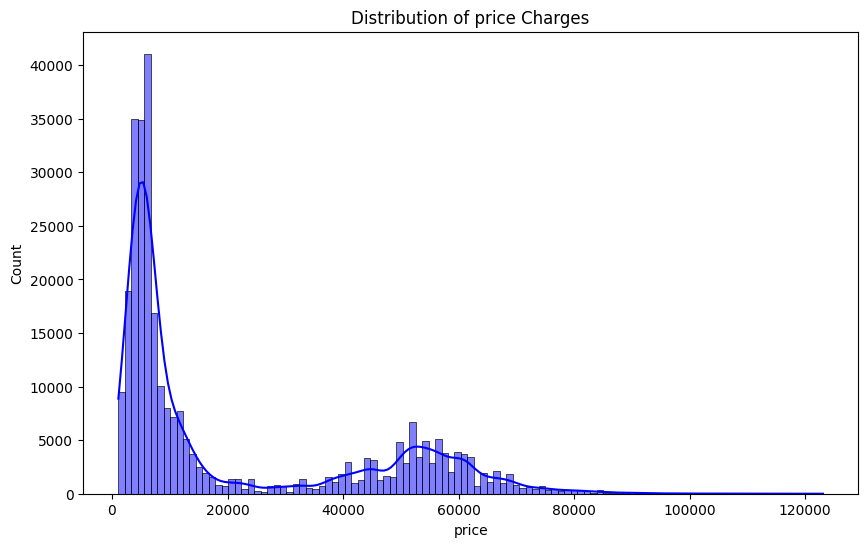

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="price",kde=True,color="blue")
plt.title("Distribution of price Charges")
plt.show()

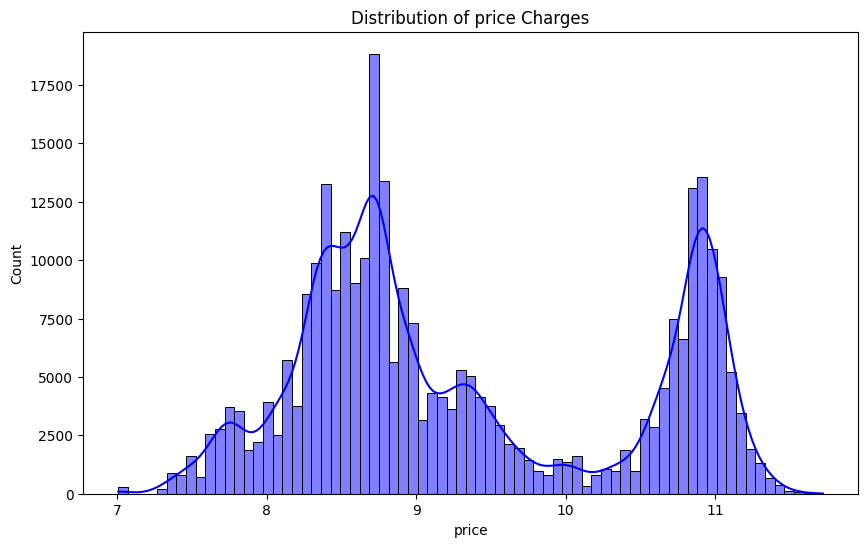

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x=np.log1p(df['price']),kde=True,color="blue")
plt.title("Distribution of price Charges")
plt.show()

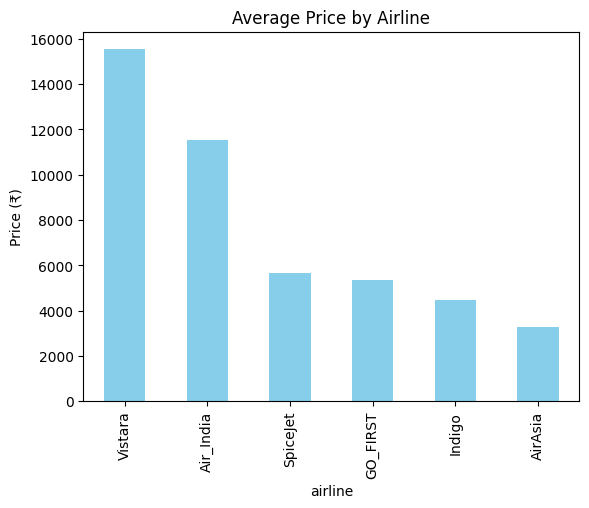

In [13]:
# Do the math manually first
airline_prices = df.groupby('airline')['price'].median().sort_values(ascending=False)

# Plot the result
airline_prices.plot.bar(color='skyblue')
plt.title("Average Price by Airline")
plt.ylabel("Price (₹)")
plt.show()

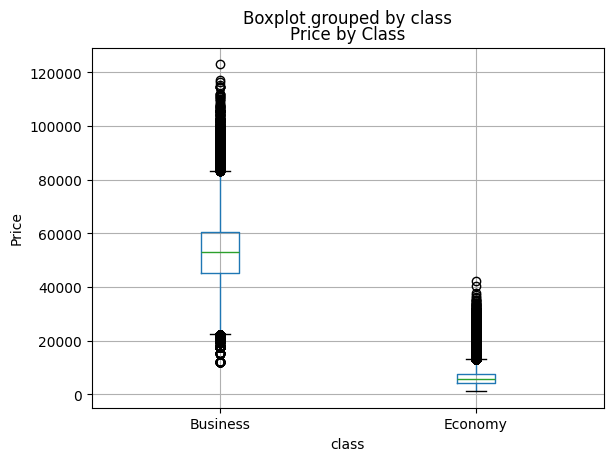

In [14]:
df.boxplot(column='price', by='class')
plt.title("Price by Class")
plt.ylabel("Price")
plt.show()

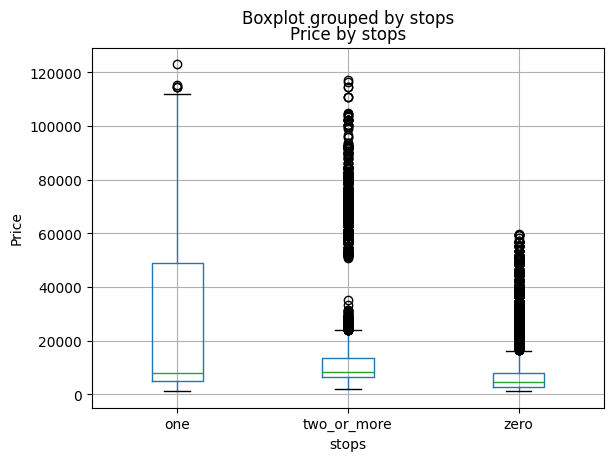

In [15]:
df.boxplot(column='price', by='stops')
plt.title("Price by stops")
plt.ylabel("Price")
plt.show()

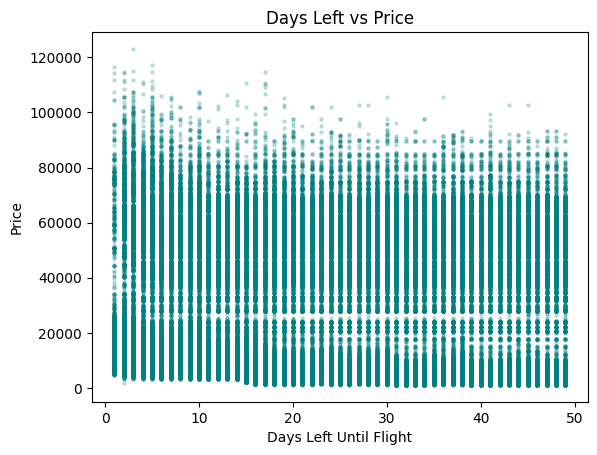

In [16]:
plt.scatter(df['days_left'], df['price'], alpha=0.2, s=5, color='teal')
plt.title("Days Left vs Price")
plt.ylabel("Price")
plt.xlabel("Days Left Until Flight")
plt.show()

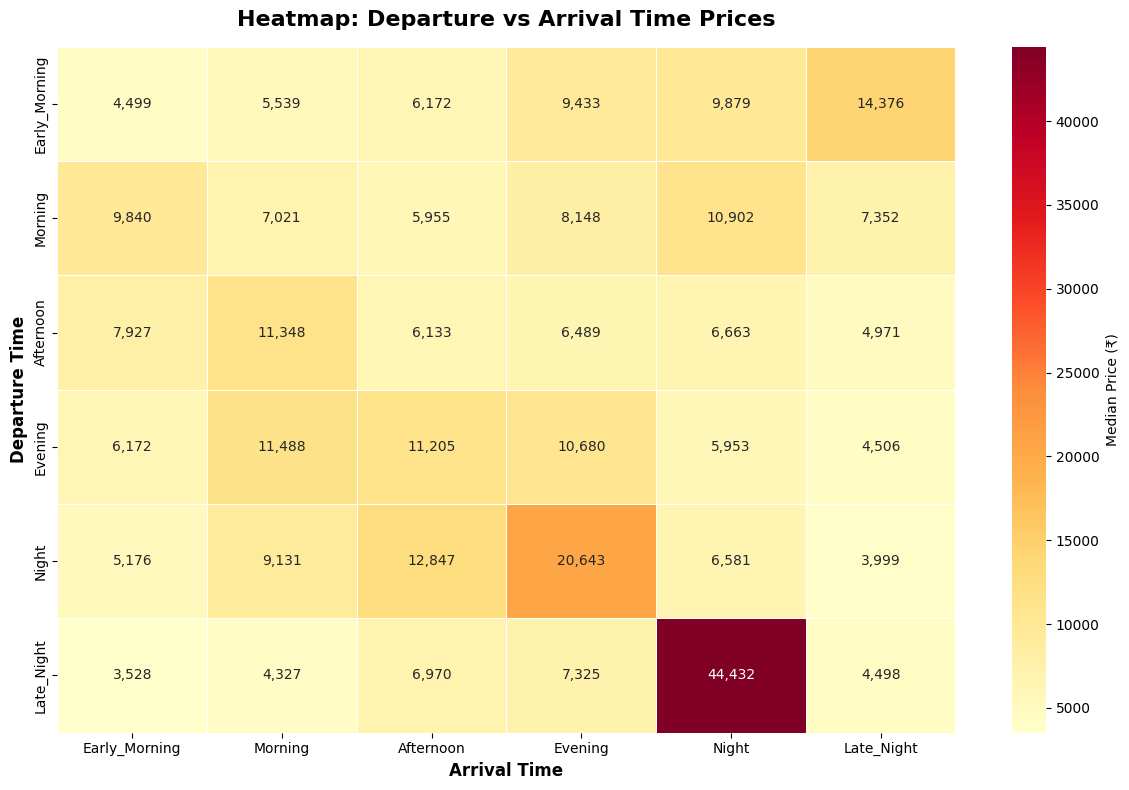

In [17]:
time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']
time_pivot = df.pivot_table(
    values='price',
    index='departure_time',
    columns='arrival_time',
    aggfunc='median'
)

valid_idx = [t for t in time_order if t in time_pivot.index]
valid_col = [t for t in time_order if t in time_pivot.columns]
time_pivot = time_pivot.loc[valid_idx, valid_col]
plt.figure(figsize=(12, 8))

sns.heatmap(time_pivot, annot=True, fmt=",.0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={'label': 'Median Price (₹)'})

plt.title("Heatmap: Departure vs Arrival Time Prices", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Arrival Time", fontsize=12, fontweight='bold')
plt.ylabel("Departure Time", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

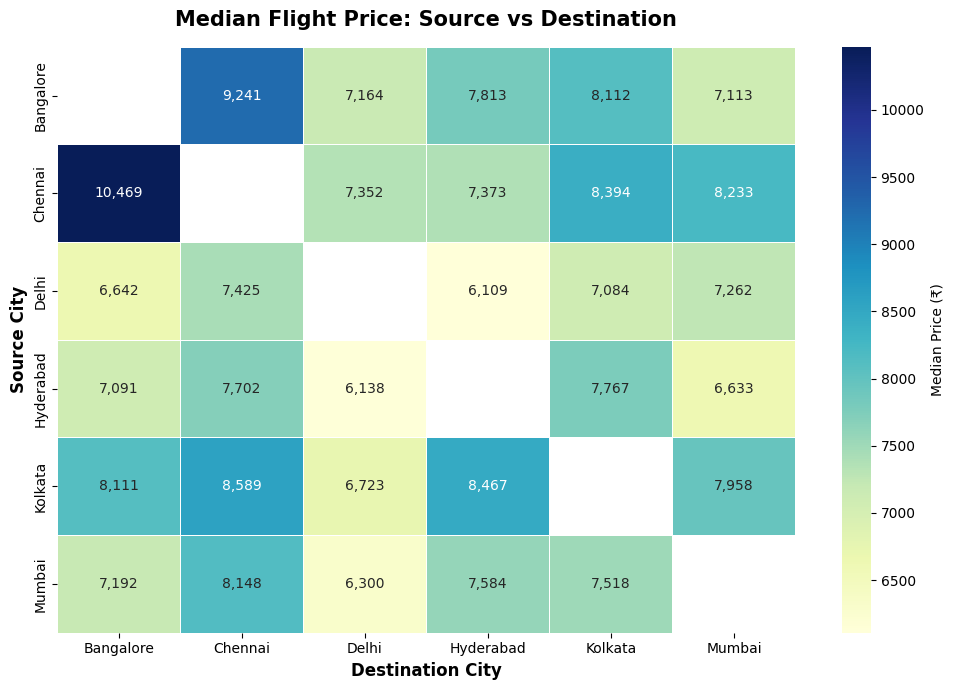

In [18]:
route_pivot = df.pivot_table(
    values='price',
    index='source_city',
    columns='destination_city',
    aggfunc='median'
)

# Plot the Heatmap
plt.figure(figsize=(10, 7))

# a blue/green color map here to differentiate it from the Time heatmap
sns.heatmap(route_pivot, annot=True, fmt=",.0f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={'label': 'Median Price (₹)'})

plt.title("Median Flight Price: Source vs Destination", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Destination City", fontsize=12, fontweight='bold')
plt.ylabel("Source City", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

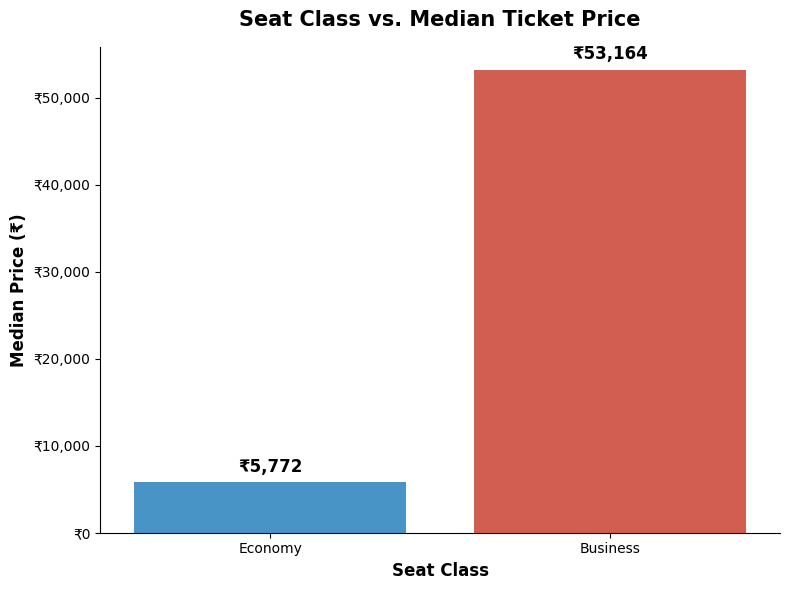

In [19]:
plt.figure(figsize=(8, 6))

# a simple bar chart comparing the median price of the two classes
ax = sns.barplot(
    data=df,
    x='class',
    y='price',
    estimator=np.median,
    errorbar=None,
    palette=['#3498DB', '#E74C3C'] # Blue for Economy, Red for Business
)

# exact Rupee text labels on top of the bars
for p in ax.patches:
    ax.annotate(f'₹{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')

# Clean up the titles and axes
plt.title("Seat Class vs. Median Ticket Price", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Seat Class", fontsize=12, fontweight='bold')
plt.ylabel("Median Price (₹)", fontsize=12, fontweight='bold')

# Format Y-axis to show Rupees cleanly
formatter = FuncFormatter(lambda y, pos: f'₹{int(y):,}')
plt.gca().yaxis.set_major_formatter(formatter)

sns.despine()
plt.tight_layout()
plt.show()

### 🔍 Data Cleaning & Outlier Strategy

---

#### **1. Missing Value Assessment**
> Running `df.info()` reveals a perfectly clean structural framework with **zero missing values** across all columns. No imputation steps are required.

#### **2. Advanced Outlier Handling**
Rather than adhering to standard procedures that clip the top and bottom $5\%$ of the distribution, we modified our approach to a strict **$0.5\%$ threshold**:

* **The Problem with $5\%$ Clipping:** Removing $5\%$ of the data at both tails would result in a massive loss of valuable operational data points, over-sanitizing the dataset.
* **The $0.5\%$ Solution:** Trimming just the extreme $0.5\%$ allows us to target and remove genuine anomalies (such as extreme pricing anomalies or data entry glitches) without sacrificing the natural real-world variation of airline pricing.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   source_city       300153 non-null  object 
 2   departure_time    300153 non-null  object 
 3   stops             300153 non-null  object 
 4   arrival_time      300153 non-null  object 
 5   destination_city  300153 non-null  object 
 6   class             300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 22.9+ MB


In [21]:
before=len(df)
q1  = df['price'].quantile(0.005)
q99 = df['price'].quantile(0.995)
df  = df[(df['price'] >= q1) & (df['price'] <= q99)]
print(f"Rows before outlier removal : {before}")
print(f"Rows after  outlier removal : {len(df)}")
print(f"Removed {before - len(df)} extreme price rows (bottom 0.5% / top 0.5%)")

Rows before outlier removal : 300153
Rows after  outlier removal : 297174
Removed 2979 extreme price rows (bottom 0.5% / top 0.5%)


# FUNCTION TRANSFORMATION (Log Target)

In [22]:
skew_before = df['price'].skew()
df['price_log'] = np.log1p(df['price'])
skew_after  = df['price_log'].skew()
print(f"Price skewness BEFORE log transform : {skew_before:.4f}")
print(f"Price skewness AFTER  log transform : {skew_after:.4f}")
print("(Closer to 0 = more normal = better for linear regression)")

Price skewness BEFORE log transform : 1.0274
Price skewness AFTER  log transform : 0.4241
(Closer to 0 = more normal = better for linear regression)


## Feature Encoding Strategy (Mixed Variables)

Because our dataset contains a mix of different categorical data types, we cannot blindly apply one encoding method to everything. We must intentionally choose our encoders based on whether the data has a mathematical ranking.

### 1. One-Hot Encoding (OHE) for Airlines & Cities
* **Why use OHE?** Variables like `airline` (Indigo, Vistara) and `city` (Delhi, Mumbai) are **Nominal**. There is no inherent mathematical ranking between them.
* **Why NOT use Ordinal?** If we used Ordinal Encoding, the computer might assign Vistara a "1" and Indigo a "3". The Machine Learning math would falsely assume that Indigo is somehow "three times greater" than Vistara. OHE prevents this false hierarchy by turning each category into an independent `1` or `0` switch.

### 2. Ordinal Encoding for 'Stops'
* **Why use Ordinal?** The `stops` variable (Zero, One, Two_or_more) is **Ordinal**. There is a strict, logical progression.
* **Why NOT use OHE?** Using OHE here would destroy the mathematical relationship. We *want* the algorithm to know that 2 stops is mathematically larger than 0 stops, because more stops directly correlate to travel time and price. Ordinal encoding (`0, 1, 2`) perfectly preserves this natural ranking.

### 3. Binary Encoding for 'Class' (Economy vs. Business)
* **Why use Binary?** Because there are only two possible states, we only need a single column where `0 = Economy` and `1 = Business`.
* **Why NOT use OHE?** Using OHE would create two separate columns (`is_Economy` and `is_Business`). This creates a problem called the **Dummy Variable Trap** (perfect multicollinearity). If a model knows the flight is *not* Economy, it already implicitly knows it *must* be Business. The second column is redundant, wastes memory, and confuses Linear Regression algorithms.

In [23]:
df['class_encoded'] = df['class'].map({'Economy': 0, 'Business': 1})
print("Binary encoded  : 'class'  →  Economy=0, Business=1")

Binary encoded  : 'class'  →  Economy=0, Business=1


In [24]:
stops_order = {'zero': 0, 'one': 1, 'two_or_more': 2}
df['stops_encoded'] = df['stops'].map(stops_order)
print("Ordinal encoded : 'stops'  →  zero=0, one=1, two_or_more=2")

Ordinal encoded : 'stops'  →  zero=0, one=1, two_or_more=2


In [25]:
time_order = {
    'Early_Morning': 0, 'Morning': 1, 'Afternoon': 2,
    'Evening': 3, 'Night': 4, 'Late_Night': 5
}
df['dep_time_encoded'] = df['departure_time'].map(time_order)
df['arr_time_encoded'] = df['arrival_time'].map(time_order)
print("Ordinal encoded : 'departure_time' and 'arrival_time'")

Ordinal encoded : 'departure_time' and 'arrival_time'


In [26]:
df = pd.get_dummies(df,
    columns=['airline', 'source_city', 'destination_city'],
    drop_first=True)
print("One-Hot encoded : 'airline', 'source_city', 'destination_city'")

One-Hot encoded : 'airline', 'source_city', 'destination_city'


# FEATURE CONSTRUCTION

In [27]:
df['duration_mins'] = (df['duration'] * 60).astype(int)
print("New feature: 'duration_mins' = duration × 60")

# Is it a direct flight?
df['is_direct'] = (df['stops_encoded'] == 0).astype(int)
print("New feature: 'is_direct'  →  1 if zero stops, else 0")

# Booking window category encoded as number
df['booking_window'] = pd.cut(
    df['days_left'],
    bins=[0, 7, 14, 30, 60, 999],
    labels=[0, 1, 2, 3, 4]
).astype(int)
print("New feature: 'booking_window'  →  binned days_left into 5 categories")

# Time gap between departure and arrival bins
df['time_shift'] = df['arr_time_encoded'] - df['dep_time_encoded']
print("New feature: 'time_shift'  →  arrival_time_bin − departure_time_bin")

print(f"\nDataset shape after feature construction: {df.shape}")

New feature: 'duration_mins' = duration × 60
New feature: 'is_direct'  →  1 if zero stops, else 0
New feature: 'booking_window'  →  binned days_left into 5 categories
New feature: 'time_shift'  →  arrival_time_bin − departure_time_bin

Dataset shape after feature construction: (297174, 31)


# FEATURE SELECTION — Drop Raw Columns

In [28]:
cols_to_drop = [
    'departure_time', 'arrival_time', 'stops',
    'class', 'duration', 'price'
]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [29]:
target = 'price_log'
X = df.drop(columns=[target])
y = df[target]

 # TRAIN TEST SPLIT , PIPELINE (Scaling + PCA + Model), EVALUATION

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Identify numeric columns for scaling
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# ColumnTransformer: scale only numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
pipe_pca = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('model', LinearRegression())
])
pipe_lr.fit(X_train, y_train)
pipe_pca.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['days_left', 'class_encoded',
                                                   'stops_encoded',
                                                   'dep_time_encoded',
                                                   'arr_time_encoded',
                                                   'duration_mins', 'is_direct',
                                                   'booking_window',
                                                   'time_shift'])])),
                ('pca', PCA(n_components=0.95)),
                ('model', LinearRegression())])

In [32]:
def evaluate(pipe, X_test, y_test, label):
    y_pred_log = pipe.predict(X_test)
    # Convert back from log scale to actual ₹ prices
    y_pred   = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)

    mae  = mean_absolute_error(y_actual, y_pred)
    rmse = mean_squared_error(y_actual, y_pred) ** 0.5
    r2   = r2_score(y_actual, y_pred)

    print(f"\n  [{label}]")
    print(f"  MAE  (Mean Absolute Error)  : ₹{mae:,.0f}")
    print(f"  RMSE (Root Mean Sq. Error)  : ₹{rmse:,.0f}")
    print(f"  R²   (R-squared)            : {r2:.4f}")
    print(f"  Interpretation: On average, predictions are off by ₹{mae:,.0f}")

    return y_pred, y_actual

pred_lr,  actual_lr  = evaluate(pipe_lr,  X_test, y_test, "Linear Regression (No PCA)")
pred_pca, actual_pca = evaluate(pipe_pca, X_test, y_test, "Linear Regression + PCA")


  [Linear Regression (No PCA)]
  MAE  (Mean Absolute Error)  : ₹4,536
  RMSE (Root Mean Sq. Error)  : ₹7,983
  R²   (R-squared)            : 0.8711
  Interpretation: On average, predictions are off by ₹4,536

  [Linear Regression + PCA]
  MAE  (Mean Absolute Error)  : ₹4,618
  RMSE (Root Mean Sq. Error)  : ₹7,936
  R²   (R-squared)            : 0.8726
  Interpretation: On average, predictions are off by ₹4,618


# FEATURE IMPORTANCE (Coefficients),VISUALISE RESULTS and PREDICT ON A SAMPLE

In [33]:
# 1. Grab the math weights (coefficients) from the trained model
coef = pipe_lr.named_steps['model'].coef_

# 2. Get the exact column names from the preprocessor
# (This is much safer than just using 'numeric_cols')
feat_names = pipe_lr.named_steps['preprocessor'].get_feature_names_out()

# 3. Create a clean Pandas DataFrame and sort by the biggest impact
coef_df = pd.DataFrame({
    'Feature': feat_names[:len(coef)],
    'Coefficient': coef[:len(feat_names)]
})

# 4. Sort by the absolute value (biggest impact, whether positive or negative)
coef_df['Abs_Impact'] = coef_df['Coefficient'].abs()
top_10_features = coef_df.sort_values(by='Abs_Impact', ascending=False).head(10)

# Display the clean table
top_10_features[['Feature', 'Coefficient']]

,Feature,Coefficient
1,scaler__class_encoded,0.935230
13,remainder__airline_Vistara,0.646193
9,remainder__airline_Air_India,0.525078
12,remainder__airline_SpiceJet,0.468198
10,remainder__airline_GO_FIRST,0.417953
11,remainder__airline_Indigo,0.335984
7,scaler__booking_window,-0.182084
17,remainder__source_city_Kolkata,0.136841
22,remainder__destination_city_Kolkata,0.105405
21,remainder__destination_city_Hyderabad,-0.090382


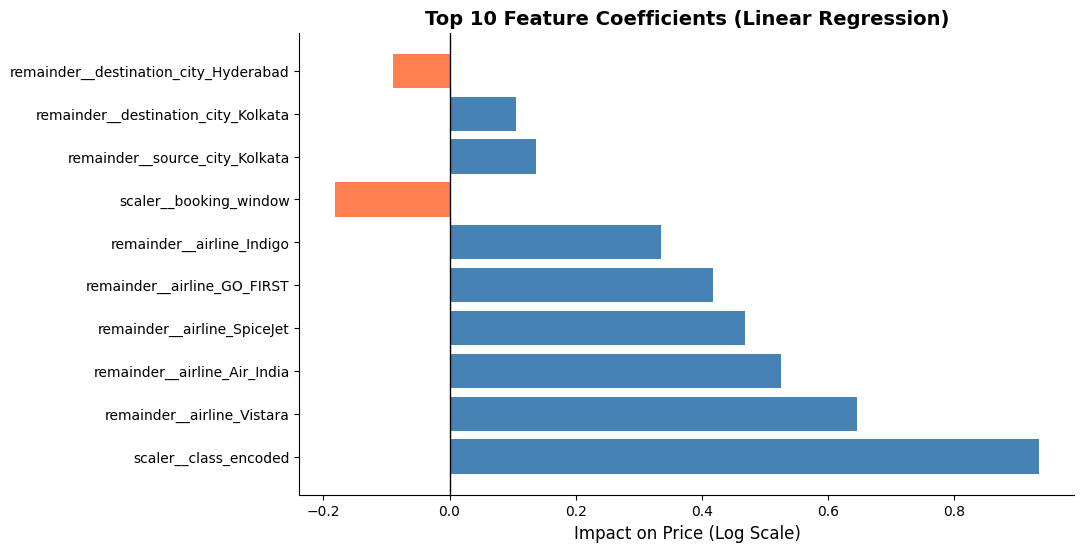

In [34]:
plt.figure(figsize=(10, 6))

# 1. Assign colors: Blue if it increases the price, Red if it decreases the price
colors = ['steelblue' if c > 0 else 'coral' for c in top_10_features['Coefficient']]

# 2. Draw the horizontal bar chart
plt.barh(top_10_features['Feature'], top_10_features['Coefficient'], color=colors)

# 3. Draw a black line at exactly zero for reference
plt.axvline(0, color='black', linewidth=1)

# 4. Add clean titles and labels
plt.title("Top 10 Feature Coefficients (Linear Regression)", fontsize=14, fontweight='bold')
plt.xlabel("Impact on Price (Log Scale)", fontsize=12)

# 5. Show it directly on the screen! (No need to save to a file)
sns.despine()
plt.show()

In [38]:
# 1. Grab the very first row of your testing data
sample_flight = X_test.iloc[[0]]

# 2. Ask the pipeline to predict the price (it returns a log number)
pred_log = pipe_lr.predict(sample_flight)[0]

# 3. Reverse the math (np.expm1) to get the REAL Rupee amounts
pred_price = np.expm1(pred_log)
actual_price = np.expm1(y_test.iloc[0])

# 4. Print the final results nicely
print(f" ACTUAL Price    : ₹{actual_price:,.2f}")
print(f" PREDICTED Price : ₹{pred_price:,.2f}")
print("-" * 35)
print(f" Difference      : ₹{abs(actual_price - pred_price):,.2f}")

 ACTUAL Price    : ₹9,241.00
 PREDICTED Price : ₹8,344.50
-----------------------------------
 Difference      : ₹896.50


## Actual vs Predicted (Scatterplot) AND Residual Distribution (Error curve)


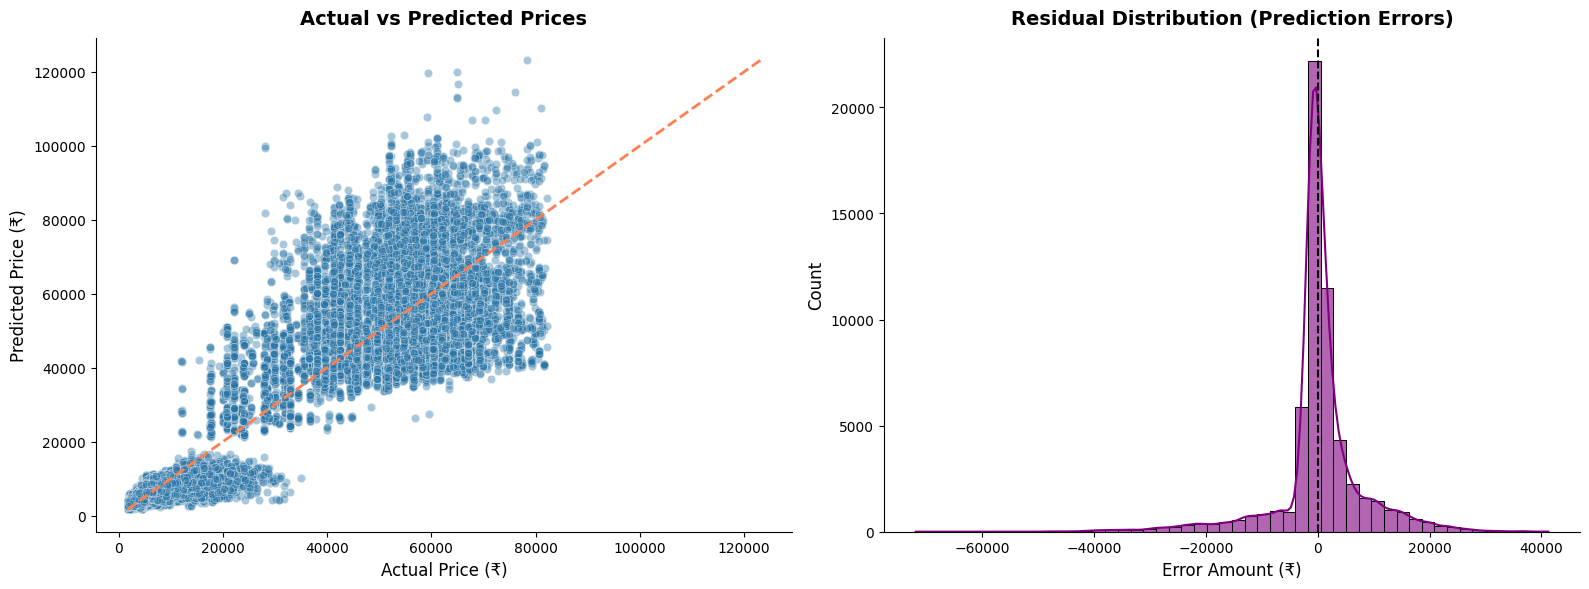

In [36]:
y_pred_log = pipe_lr.predict(X_test)

# 2. Reverse the math to get actual Rupees (since you used log transformation)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# 3. Calculate the residuals (How many Rupees the model was off by)
residuals = y_true - y_pred

# 4. Set up a side-by-side dashboard (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y_true, y=y_pred, alpha=0.4, color='#2874A6', ax=axes[0])

# Draw the "Perfect Prediction" dashed line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='coral', linestyle='--', linewidth=2)

axes[0].set_title("Actual vs Predicted Prices", fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Actual Price (₹)", fontsize=12)
axes[0].set_ylabel("Predicted Price (₹)", fontsize=12)

sns.histplot(residuals, bins=50, kde=True, color='purple', ax=axes[1], alpha=0.6)

# Draw a line at exactly Zero error
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)

axes[1].set_title("Residual Distribution (Prediction Errors)", fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel("Error Amount (₹)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)

# Clean up the borders and show the final dashboard!
sns.despine()
plt.tight_layout()
plt.show()

In [37]:
# a blank dataframe using the exact mathematical columns from your test set
my_flight_df = pd.DataFrame(columns=X_test.columns)

# Add one row of all zeros to act as our blank canvas
my_flight_df.loc[0] = 0

# Flip the "switches" (1s) for the text data from your screenshot
if 'airline_SpiceJet' in my_flight_df.columns: my_flight_df['airline_SpiceJet'] = 1
if 'source_city_Delhi' in my_flight_df.columns: my_flight_df['source_city_Delhi'] = 1
if 'destination_city_Mumbai' in my_flight_df.columns: my_flight_df['destination_city_Mumbai'] = 1


my_flight_df['days_left'] = 1
my_flight_df['is_direct'] = 1        # Because it has 0 stops
my_flight_df['stops_encoded'] = 0    # 0 stops
my_flight_df['class_encoded'] = 0    # Usually 0 is Economy, 1 is Business

if 'duration_mins' in my_flight_df.columns:
    my_flight_df['duration_mins'] = 2.17 * 60
else:
    my_flight_df['duration'] = 2.17

# Predict the price
predicted_log = pipe_lr.predict(my_flight_df)[0]
final_price = np.expm1(predicted_log)

print(f"✈️ Predicted Price for this SpiceJet flight: ₹{final_price:,.2f}")

✈️ Predicted Price for this SpiceJet flight: ₹5,331.49


# RESEARCH QUESTION

## a) Does price vary with Airlines?
=> Yes, price varies significantly across airlines, revealing a strict divide between premium and budget carriers.
As demonstrated in the Median Price by Airline chart, the airline chosen is a major determining factor in the baseline ticket cost. The data naturally clusters into two distinct pricing tiers:
The Premium Tier (Vistara & Air India): Vistara commands the highest prices by a wide margin, followed by Air India. Their median ticket prices are drastically higher than the rest of the market. This massive price gap is primarily driven by seat class availability; Vistara and Air India are the only airlines in this dataset that offer highly expensive Business Class tickets, which pulls their median price upward.
The Budget Tier (SpiceJet, AirAsia, GO FIRST, Indigo): The remaining four airlines operate in a highly competitive, low-cost bracket. Their median prices are tightly clustered together at the bottom of the chart. Because these airlines strictly offer Economy class seating, their baseline prices remain uniformly low and accessible.

## b)How is the price affected when tickets are bought in just 1 or 2 days before departure?

=> The "Sweet Spot" (15 to 45 days): Look at how flat the line is on the left side of the chart. It proves that booking a month in advance gets you the baseline, standard price. There is no real financial benefit to booking 45 days in advance versus 20 days in advance.

The "Danger Zone" (The red shaded area): As the x-axis counts down to 1, the price violently spikes upward. The visual of the red line shooting up right as it enters your "Last-Minute Surge" box is undeniable proof of the airline's panic-booking algorithm.

## c) Does ticket price change based on the departure time and arrival time?
=>Yes, ticket prices fluctuate based on flight times, largely driven by passenger convenience and business travel patterns.

As visualized in the Departure vs. Arrival Time Heatmap, airlines dynamically adjust prices based on the time of day. Instead of a random spread of prices, the data reveals distinct "zones" of demand:

The "Convenience Premium" (Peak Hours): The most expensive flights (the darkest red/orange squares on the heatmap) typically involve departures and arrivals during prime waking hours—specifically Morning and Evening. These times are highly desirable for corporate flyers traveling for meetings, and vacationers who want to maximize their day without disrupting their sleep schedules. Because demand is highest here, airlines charge a premium.

The "Red-Eye Discount" (Off-Peak Hours): The cheapest flights (the lightest yellow squares) are almost universally concentrated around Late Night and Early Morning times. Because flying at 2:00 AM or arriving at 4:00 AM is highly inconvenient and exhausting for most passengers, airlines must heavily discount these tickets to incentivize travelers to fill the empty seats.

## d)How does the price change with a change in Source and Destination?
=> Route selection heavily influences the median ticket price, primarily driven by flight distance and regional hub demand.

As visualized in the Source vs. Destination Heatmap, flight prices are not uniform across the country. The data reveals distinct pricing tiers based on the specific route:

The Premium Routes (The Dark Blue/Green Zones): Flights involving Southern and Eastern hubs tend to carry higher baseline prices. For example, traveling from Chennai to Bangalore commands the highest median price in the dataset (₹8,241), closely followed by routes like Chennai to Kolkata (₹7,868). This is largely due to the longer physical distances involved, which require more fuel, alongside specific airport taxation and corporate demand in these tech hubs.

The Budget Routes (The Yellow Zones): Conversely, routes involving Delhi tend to be highly competitive and cheaper. Flying from Delhi to Hyderabad (₹5,142) or Delhi to Mumbai (₹5,955) represents some of the most affordable median travel in the dataset. Because these are highly trafficked "trunk routes," multiple airlines constantly undercut each other to fill seats, driving the baseline price down.

## e)How does the ticket price vary between Economy and Business class?
=>Seat class is the single most dominant factor in airline pricing, creating two entirely separate financial ecosystems.

The Seat Class vs. Median Ticket Price bar chart completely proves the initial hypothesis: Business Class is not simply a price modification; it is an entirely different pricing bracket.

The Baseline Market (Economy): The median price of an Economy ticket sits at ₹7,418. This represents the highly competitive, accessible tier of air travel where airlines fight over small profit margins and budget flyers.

The Luxury Multiplier (Business): The median price of a Business Class ticket explodes to ₹54,208. This means a standard Business Class seat is over 7 times more expensive than its Economy equivalent.